#### PCA  - Dimensionality reduction of feature space using  (PCA vasitəsilə xüsusiyyətlər məkanının ölçüsünün azaldılması)

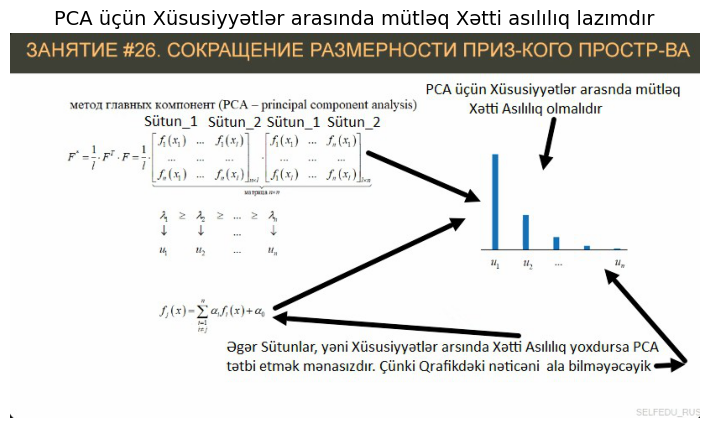

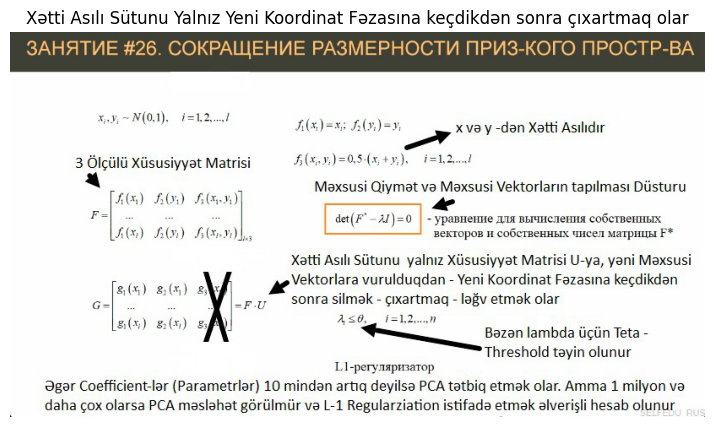

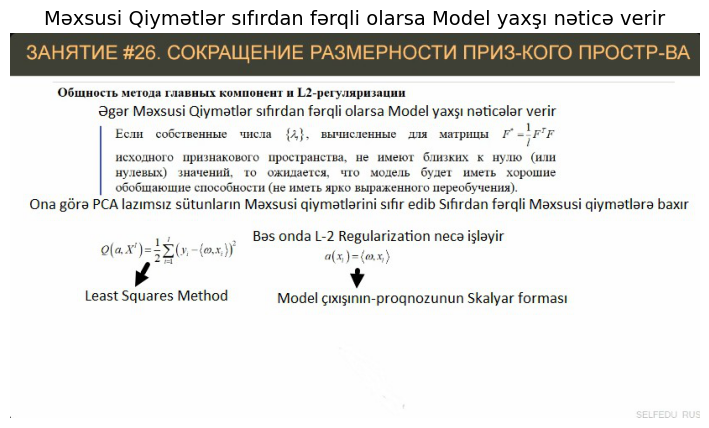

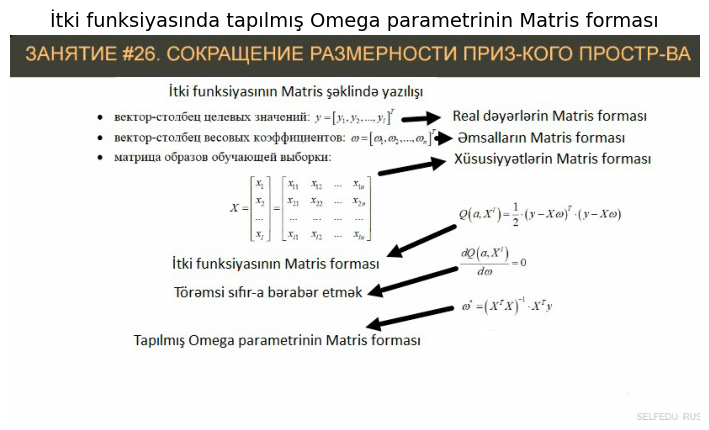

In [6]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_26_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 5):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""PCA üçün Xüsusiyyətlər arasında mütləq Xətti asılılıq lazımdır""", size='14')
    elif i < 2:
        plt.title("""Xətti Asılı Sütunu Yalnız Yeni Koordinat Fəzasına keçdikdən sonra çıxartmaq olar""", size='12')
    elif i < 3:
        plt.title("""Məxsusi Qiymətlər sıfırdan fərqli olarsa Model yaxşı nəticə verir""", size='14') 
    elif i < 4:
        plt.title("""İtki funksiyasında tapılmış Omega parametrinin Matris forması""", size='14')        
        
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()


### **İki sutun arasinda COVARİANCE və Correlation varsa bu Xətti Asılılq demekdir**

#### **Aydın izah:**

* **Kovarians ≠ 0** və ya **korelyasiya ≠ 0**
  - **👉 bu o deməkdir ki, iki dəyişən arasında xətti asılılıq var**

* **Korelyasiya (correlation)** xüsusilə:

  * **+1** → güclü **müsbət xətti əlaqə**
  * **-1** → güclü **mənfi xətti əlaqə**
  * **0** → **xətti əlaqə yoxdur**

<br>

#### **Amma vacib nüans ⚠️**

> **Korelyasiya = 0 olsa belə, bu o demək deyil ki, ümumiyyətlə əlaqə yoxdur.**

- **Məsələn:**
    * ( $y = x^2$)
    - **👉 burada güclü əlaqə var**
    - **👉 amma xətti deyil, ona görə korelyasiya ≈ 0 çıxa bilər**

<br>

#### **Nəticə:**

* **✔️ Kovarians / korelyasiya varsa → xətti əlaqə var**
* **❗ Amma yoxdursa → ümumiyyətlə əlaqə yoxdur demək deyil, sadəcə xətti deyil**



#### **PCA əsasən dəyişənlər arasında xətti asılılıq (korelyasiya / kovarians) varsa istifadə olunur**

#### **Niyə?**

- **PCA-nın əsas məqsədi:**

> - **1. Bir-biri ilə korelyasiyalı (yəni məlumatı təkrarlayan) sütunları tapmaq**
> - **2. Onları daha az sayda yeni dəyişənə (principal components) çevirmək**

<br>

#### **Sadə məntiq:**

- **Əgər sütunlar bir-birindən asılıdırsa (xətti əlaqə var)**
- **👉 PCA bunu “tutur” və ölçünü azaldır ✅**

<br>

- **Əgər sütunlar tam müstəqildirsə (korelyasiya ≈ 0)**
- **👉 PCA çox fayda vermir ❌**

<br>

#### **Vacib nüans:**

- **PCA yalnız:**
- **👉 xətti əlaqələri (linear patterns) görür**
- **👉 qeyri-xətti əlaqələri (məsələn $x^2$) yaxşı tuta bilmir**

<br>

#### **Nəticə:**

- **✔️ Korelyasiya varsa → PCA çox effektivdir**
- **❗ Korelyasiya yoxdursa → PCA faydası az olur**


#### **PCA tətbiq edərkən $z$ üçün eigenvalue = $0$ olur, çünki $z$ digər sütunların xətti kombinasiyasıdır → yeni informasiya daşımır**

- **PCA-nın “ürəyi”:**
    - 👉 **z üçün eigenvalue = 0 olur, çünki z digər sütunların xətti kombinasiyasıdır → yeni informasiya daşımır**

<br>

####  **Mənzərə:**

* $ x $
* $ y $
* $ z = \frac{x + y}{2} $

- **Bu o deməkdir ki:**
    - 👉 **z tam olaraq x və y-dən asılıdır (linear dependent)**

<br>

#### **Riyazi məntiq:**

- **Bu üç dəyişən əslində 3 ölçülü deyil ❗ :**
    - 👉 **realda 2 ölçülüdür**

- **Yəni:**
    - **3 sütun var**
    - **amma rank = 2**

<br>

#### **PCA nə edir?**

- **PCA kovarians matrisinin eigenvalue-larını tapır:**
    * **böyük eigenvalue → çox informasiya (variance)**
    * **kiçik eigenvalue → az informasiya****
    * **0 eigenvalue → heç bir yeni informasiya yoxdur**

<br>

#### **Case:**

* **1-ci component → əsas variasiya ($x$ və $y$ istiqaməti)**
* **2-ci component → ikinci variasiya (ona perpendikulyar ikinci yayılma - qalan “yayılmanın” ən çox olduğu istiqamət)**
* **3-cü component → 0 (çünki $z$ redundantdır)**

<br>

#### **Intuitiv izah:**

- **z artıq x və y-nin içində var:**
    - **👉 PCA deyir ki:**
    - **Bu istiqamətdə $z$ hərəkət etsəm yeni heç nə öyrənmirəm”**

<br>

#### **Əsas Məntiq - Nəticə:**

> - ✔️ $ z = \frac{x + y}{2} $ → **tam xətti asılılıq**
> - ✔️ **buna görə bir eigenvalue = 0**
> - **✔️ 1. PCA "Silmir", Sıfıra Endirir:**
    - **PCA riyazi olaraq heç nəyi silmir; o, sadəcə bütün sütunları yeni oxlara (komponentlərə) transformasiya edir.**
    - **Əgər iki sütun tam eynidirsə, PCA onları elə birləşdirir ki, bütün məlumat 1-ci komponentdə cəmləşir.**
    - **Nəticədə 2-ci komponentin eigenvalue göstəricisi sıfır olur.**
> - **✔️2. Biz Onu Atırıq (Dimensionality Reduction)**
    - **Riyazi olaraq o komponent orada mövcud olsa da, biz praktikada onu istifadə etmirik. Çünki:**
    - **Eigenvalue = 0 → Bu komponentdə məlumat yoxdur.**
    - **Məlumat yoxdursa → Bu komponentin modelə heç bir köməyi yoxdur.**
> - **✔️ Xülasə PCA-da proses belə gedir:**
    - **Birləşdirmə: Bütün sütunlar bir qazana atılır və yeni komponentlər yaradılır.**
    - **Sıralama: Bu komponentlər eigenvalue dəyərlərinə görə (çox məlumatdan az məlumat sayına doğru) düzülür.**
    - **Kəsmə: Biz qərar veririk ki, "0" və ya "0.0001" olan komponentlər bizə lazım deyil.**
    
<br>

- **Yekun :**
> **PCA məlumatı yeni formaya salır (birləşdirir), nəticədə artıq qalan "boş" hissələrin eigenvalue dəyəri sıfır olur. Biz isə o sıfırları sadəcə nəzərə almırıq. Beləliklə, məlumatın həcmi kiçilir, amma keyfiyyəti (məlumatlılığı) qorunur.**

### **PCA-nın yanaşması birini silmək yox, birləşdirməkdir.**

#### **Qısa izah:**
* **Səhv anlaşılan:** **Əgər iki sütun (məsələn, $X_1$ və $X_2$) bir-biri ilə yüksək korrelyasiyadadırsa, PCA onlardan birini zibil qutusuna atmır.**
* **Doğru olan:** **PCA bu iki sütundakı məlumatın ən yaxşı "qarışığını" yaradan yeni bir ox (Principal Component) hesablayır. Bu yeni ox hər iki sütunun ən vacib xüsusiyyətlərini özündə cəmləşdirir.**

<br>

#### **Niyə silmir, birləşdirir?**
- **Siz bir sütunu silsəniz, o sütuna xas olan az miqdarda da olsa unikal məlumatı itirirsiniz. PCA isə məlumatı itirmək yerinə, onları transformasiya edərək daha az sayda, lakin daha informativ yeni dəyişənlərə çevirir.**

#### **Xülasə:** 
> **Sütun silmək Feature Selection (Mövcud olanlardan birini seçmək)**

> **PCA isə Feature Extraction (Mövcud olanlardan yenisini yaratmaq) metodudur.**

#### **Python kodu - PCA metodu ilə Xətti Asılı Sütunun - Xüsusiyyətin heç bir informasiya daşımadığının sübutu**
- #### **Yaradılan Xətti Asılı Sütunun $\lambda$-sı, yəni eigenvalue-sı 'sıfır'(0) oldu**

In [34]:
# numpy kitabxanasını import edirik (riyazi əməliyyatlar və massivlər üçün)
import numpy as np
# qrafik çəkmək üçün matplotlib kitabxanasını import edirik
import matplotlib.pyplot as plt

# yaradılacaq təsadüfi nümunələrin sayını təyin edirik
SIZE = 1000
# random ədədlərin hər dəfə eyni çıxması üçün seed veririk (təkrarolunanlıq üçün)
np.random.seed(123)
# normal paylanmadan 1000 ədəd təsadüfi x dəyərləri yaradırıq
x = np.random.normal(size=SIZE)
# normal paylanmadan 1000 ədəd təsadüfi y dəyərləri yaradırıq
y = np.random.normal(size=SIZE)

# z dəyişəni x və y-nin ortası kimi yaradılır (linear kombinasiyadır)
# z-i  x və y  ilə Xətti Asılı olaraq yaradılır: z  x və y-in  Xətti kombinasiyadır
z = (x + y) / 2

# x, y, z vektorlarını birləşdirib 3x1000 ölçülü matris yaradırıq
F = np.vstack([x, y, z])
# kovariasiya matrisinə bənzər matris hesablayırıq: (1/N) * F * F^T
FF = 1 / SIZE * F @ F.T
# FF matrisinin öz qiymətlərini (eigenvalues) və öz vektorlarını (eigenvectors) tapırıq
L, W = np.linalg.eig(FF)
# hər bir eigenvalue ilə uyğun eigenvectoru cütləyirik və böyükdən kiçiyə sıralayırıq
WW = sorted(zip(L, W.T), key=lambda lx: lx[0], reverse=True)
# yalnız eigenvectorları götürüb yenidən massivə çeviririk (artıq sıralanmış vəziyyətdə)
WW = np.array([w[1] for w in WW])

# eigenvalue-ları böyükdən kiçiyə sıralayıb çap edirik: 
# np.sort(L) → sıralayır, [::-1] → tərsinə çevirir (descending), .tolist() → numpy tipini adi Python list-ə çevirir
print(f"eigenvalues (lambda-lar): {np.sort(L)[::-1].tolist()}")

eigenvalues (lambda-lar): [1.4018930165258354, 0.9841864212968794, 0.0]


#### **ML-də xətti əlaqə (multicollinearity) problem, Qeyri-xətti əlaqə (məs: $x^2$) isə faydalı ola bilər**

> 👉 **Bəli — ML-də əsas problem xətti əlaqədir (multicollinearity).**

> 👉 **Qeyri-xətti əlaqə (məs: (x^2)) isə problem deyil, əksinə faydalı ola bilər.**

<br>

#### **🔹 1. Xətti əlaqə niyə problemdir?**

- **Məsələn:**

    * ( $z = x + y$ )

    - 👉 **Bu zaman sütunlar bir-birini “təkrarlayır”**
    - 👉 **Model (xüsusilə Linear Regression) çaşır:**
        * **koeffisiyentlər qeyri-sabit olur**
        * **interpretasiya çətinləşir**

<br>

#### **🔹 2. Qeyri-xətti əlaqə (məs: $x^2$) necədir?**

- **Məsələn:**

    * ( $y = x^2$ )

    - **👉 Bu xətti deyil, ona görə:**
        * **korelyasiya ≈ 0 ola bilər**
        * **amma realda güclü əlaqə var**

<br>

#### **ML üçün bu nə deməkdir?**

<br>

#### **✔️ Linear modellər üçün:**

* $x$ və $x^2$ **əlavə etmək yaxşıdır**
* **çünki modelə daha çox pattern öyrədir**

- **👉 buna deyilir:**
    **feature engineering**

<br>

#### **✔️ Tree-based modellər üçün (Decision Tree, XGBoost və s.):**

* **onlar özləri qeyri-xətti əlaqəni tutur**
* **(x^2) əlavə etməyə çox ehtiyac olmur**

<br>

#### **🔹Amma diqqət ⚠️**

* **Əgər çox çox belə transformasiya etsən:**

  * **overfitting ola bilər**

<br>

#### **🔹 Nəticə:**

* **❌ Xətti asılılıq → problemdir**
* **✅ Qeyri-xətti əlaqə → çox vaxt faydalıdır**
* **🚀 $x^2, \log(x)$ kimi feature-lar → modeli gücləndirir**


### **Feature Engineering Cheat Sheet**

#### **🔹 1. Linear modellər üçün**

- **(məs: Linear Regression, Logistic Regression)**

#### **Problem:**

> **👉 yalnız xətti əlaqəni öyrənir**

#### **Həll:**

- **👉 özün əlavə et:**

    * $ x^2 $ → **parabola**
    * $ x^3 $ → **daha kompleks**
    * $ \log(x) $ → **azalan artım**
    * $ \sqrt{x} $**
    * $ x_1 \cdot x_2 $ → **interaction**

#### **✔️ istifadə et:**

* **polynomial features**
* **scaling (çox vacib!)**

<br>

#### **🔹 2. Tree-based modellər üçün**

- **(məs: Decision Tree, Random Forest, XGBoost, LightGBM)**

#### **Xüsusiyyət:**

- 👉 **özləri qeyri-xətti əlaqəni tutur**

#### **✔️ etmə:**

* $ x^2 $, $ \log(x) $ **əlavə etməyə çox ehtiyac yoxdur**

#### **✔️ fokus:**

* **yaxşı feature seçimi**
* **missing values**
* **düzgün hyperparameter tuning**

<br>

#### **🔹 3. PCA nə vaxt istifadə olunur?**

- **👉 Principal Component Analysis**

#### **✔️ istifadə et:**

* **sütunlar arasında korelyasiya yüksəkdirsə**
* **ölçü çoxdursa (high dimensional data)**

#### **❌ istifadə etmə:**

* **interpretasiya vacibdirsə**
* **tree modellərdə (çox vaxt lazım deyil)**

<br>

#### **🔹 4. Multicollinearity (xətti asılılıq)**

#### **❌ problem yaradır:**

* **Linear modellərdə**

#### **✔️ həll:**

* **birini sil**
* **PCA istifadə et**
* **regularization (Ridge, Lasso)**

<br>

#### **🔹 5. Praktik qayda (ən vacib hissə 🔥)**

| **Model**             | **Feature engineering**     |
| ----------------- | ------------------------ |
| **Linear / Logistic** | **✅ çox et (x², log və s.)** |
| **Tree-based**        | **❌ az et**                 |
| **Neural Network**    |**⚖️ orta**                  |

<br>

#### **🔹 6. Qızıl qayda** 🧠

- 👉 **Model sadədirsə → sən feature-ları zənginləşdir**
- 👉 **Model güclüdürsə (tree, boosting) → feature-ları sadə saxla**